In [1]:
%reload_ext autoreload
%autoreload 2

In [4]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from flax import nnx

from probjax.nn import GaussianFourierEmbedding, Transformer
from probjax.nn.loss_fn.denoising import build_time_dependent_denoising_loss
from probjax.nn.nets.denoising_diffusion_model import EDM


In [5]:
def generate_data(key):
    # Mixture of Gaussians
    key1, key2, key3 = jax.random.split(key, 3)
    theta = jax.random.normal(key1, (1,))*2
    x = jnp.sin(theta) + jax.random.normal(key2, (1,))*0.1

    node_ids = jnp.array([0, 1])
    node_values = jnp.array([theta,x])
    return node_ids, node_values


In [6]:
keys = jax.random.split(jax.random.PRNGKey(0), 1000)
node_ids, node_values = jax.vmap(generate_data)(keys)

In [7]:
std0 = node_values.std(0)
std0

Array([[1.874],
       [0.717]], dtype=float32)

In [8]:

class Simformer(nnx.Module):

    model_dim: int = 50
    condition_dim: int = 10
    num_heads: int = 4
    num_layers: int = 4
    attn_size: int = 10


    def __init__(self, num_nodes,rngs) -> None:
        value_dim = (self.model_dim - self.condition_dim) // 2
        node_ids_dim = self.model_dim - self.condition_dim - value_dim
        self.time_embedding = GaussianFourierEmbedding(1,self.model_dim, rngs=rngs)
        self.embed_id = nnx.Embed(num_nodes, node_ids_dim, rngs=rngs)
        self.embed_value = nnx.Linear(1, value_dim, rngs=rngs)
        self.condition_token = nnx.Param(0.01*jax.random.normal(rngs.next(), (1,10)))
        self.out_layer = nnx.Linear(self.model_dim, 1, rngs=rngs)
        self.transformer = Transformer(
                                    self.model_dim,
                                    num_heads=self.num_heads,
                                    num_layers=self.num_layers,
                                    attn_size=self.attn_size,
                                    rngs=rngs,
                                    context_dim=self.model_dim,
                                    )


    def __call__(self, t,x, node_ids,condition_mask, *args,**kwargs):
        time_embed = self.time_embedding(t)
        node_embed = self.embed_id(node_ids)
        value_embed = self.embed_value(x)
        condition_embed = self.condition_token.value * condition_mask[...,None]
        input_embed = jnp.concatenate([node_embed, value_embed, condition_embed], axis=-1)

        while time_embed.ndim < input_embed.ndim:
            time_embed = time_embed[None, ...]

        output = self.transformer(input_embed, context=time_embed)
        output = self.out_layer(output)
        return output

net = Simformer(2,nnx.Rngs(1))
model = EDM(net, std0=1.)
params = nnx.state(model, nnx.Param)

In [9]:
model(jnp.ones((node_values.shape[0],1,1))*0.5, node_values, node_ids, jnp.zeros((node_values.shape[0], 2))).shape

(1000, 2, 1)

In [10]:
def mean_fn(t, x):
    return x

def std_fn(t, x):
    return model.std_fn(t)

denoiser_loss_fn = build_time_dependent_denoising_loss(model, mean_fn=mean_fn, std_fn=std_fn, weight_fn=model.weight_fn, axis=-2)

In [13]:
def loss_fn(params, rng):
    rng_times,rng_data, rng_loss, rng_cond = jax.random.split(rng, 4)
    nnx.update(model, params)
    logt = jax.random.normal(rng_times, shape=(1000, 1,1)) * 1.2 - 1.2
    t = jnp.exp(logt) + 0.0001
    keys = jax.random.split(rng_data, 1000)
    node_id, node_value = jax.vmap(generate_data)(keys)
    condition_mask = jax.random.bernoulli(rng_cond, 0.5, shape=(node_value.shape[0], node_value.shape[1]))

    loss = denoiser_loss_fn(t, node_value, node_id, condition_mask, loss_mask=condition_mask[...,None],rng=rng_loss)
    return jnp.mean(loss)


In [14]:
loss_fn(params, jax.random.PRNGKey(0))

Array(1.958, dtype=float32)

In [15]:

import optax

opt = optax.chain(optax.adaptive_grad_clip(10.), optax.adam(5e-4))
opt_state = opt.init(params)
@jax.jit
def update(params, opt_state, rng):
    loss, grads = jax.value_and_grad(loss_fn)(params, rng)
    updates, opt_state = opt.update(grads, opt_state, params=params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

In [16]:
key = jax.random.key(0)

In [17]:
losses = []
for i in range(2000):
    l = 0.
    for j in range(10):
        key,key_data, key_loss = jax.random.split(key, 3)
        params, opt_state, loss = update(params, opt_state,key_loss)
        l += loss
    losses.append(l/10)

In [18]:
nnx.update(model, params)

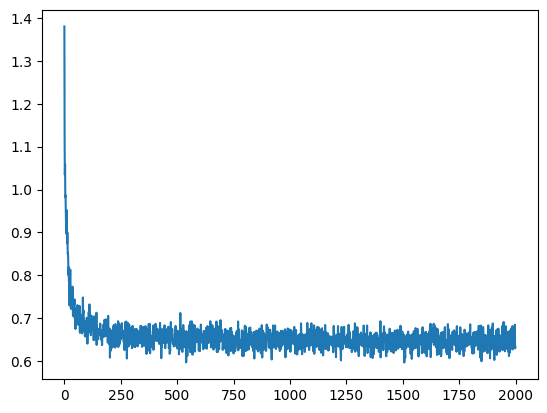

In [19]:
plt.plot(losses)

In [20]:
from probjax.utils.odeint import odeint


def sample(rng, condition_mask,x_o,T_end=80.):
    rng_init, rng_sample = jax.random.split(rng)
    eps = jax.random.normal(rng_init, (2,)) * model.marginal_std(T_end)
    ts = jnp.linspace(0.001, T_end, 200)
    eps = jnp.where(condition_mask, x_o, eps)

    def drift(t, x):
        t = jnp.atleast_1d(t)
        x_ = x.reshape((1,2,1))
        f = model.drift(t,x_)
        g = model.diffusion(t, x_)
        score = model.score(t,x_, node_ids=jnp.arange(2)[None,], condition_mask=condition_mask[None,:])
        backward_f = (f -0.5*g**2*score).reshape(x.shape)
        backward_f = jnp.where(condition_mask, 0., backward_f)
        return backward_f

    return odeint(drift, eps,ts[::-1], method="heun")


In [21]:
condition_mask = jnp.array([0,1])
x_o = jnp.array([0.,0.])

In [22]:
keys = jax.random.split(key, (10_000,))

In [23]:
xs = jax.vmap(lambda k: sample(k, condition_mask,x_o))(keys)

/tmp/ipykernel_26695/1460178256.py:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(node_values[:,0], node_values[:,1], cmap="viridis", alpha=0.5)
/tmp/ipykernel_26695/1460178256.py:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(xs[:,-1,0], xs[:,-1,1],cmap="viridis", alpha=0.05)


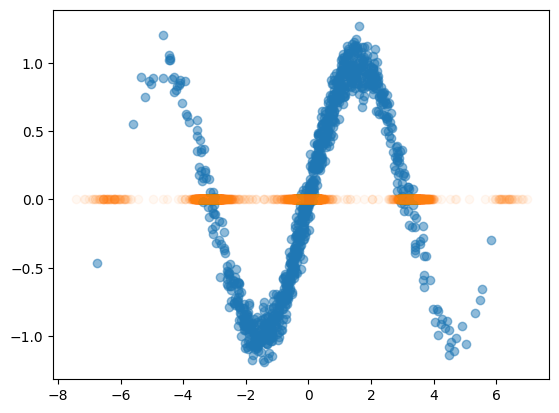

In [24]:
plt.scatter(node_values[:,0], node_values[:,1], cmap="viridis", alpha=0.5)
plt.scatter(xs[:,-1,0], xs[:,-1,1],cmap="viridis", alpha=0.05)
